In [2]:
import pandas as pd
import plotnine as p

In [28]:
df = pd.read_csv('/Users/val/Software/openTSNE/benchmarks/tsne_benchmark_results.csv')
df = df[df['method'] != 'openTSNENonMLX']

df['cores'] = df['method'].str.split('_').str[1].fillna(1).astype('str').str.replace('core', '')
df['Implementation'] = df['method'].str.split('_').str[0]

df = df[~((df['source'] == 'cuml_logs') & (df['cores'] == '12'))]

df['Platform'] = df['source'].map({'cuml_logs': 'CUDA', 'logs': 'CPU', 'mlx_logs': 'MLX'})
df['Cores'] = df['cores']

df

,dataset_size,method,runtime,source,random_state,cores,Implementation,Platform,Cores
0,1000,MLXFFT,1189.263659,mlx_logs,0,1,MLXFFT,MLX,1
1,1000,MLXFFT,1191.962099,mlx_logs,1,1,MLXFFT,MLX,1
2,1000,MLXFFT,1187.583081,mlx_logs,2,1,MLXFFT,MLX,1
3,5000,MLXFFT,6056.786343,mlx_logs,0,1,MLXFFT,MLX,1
4,5000,MLXFFT,6039.444136,mlx_logs,1,1,MLXFFT,MLX,1
...,...,...,...,...,...,...,...,...,...
204,50000,sklearn_12core,63.430178,logs,1,12,sklearn,CPU,12
206,50000,sklearn_12core,63.242946,logs,2,12,sklearn,CPU,12
208,100000,sklearn_12core,138.860699,logs,0,12,sklearn,CPU,12
210,100000,sklearn_12core,137.807499,logs,1,12,sklearn,CPU,12


/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 4 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: 250330.runtimes.png
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/stats/smoothers.py:347: Plo

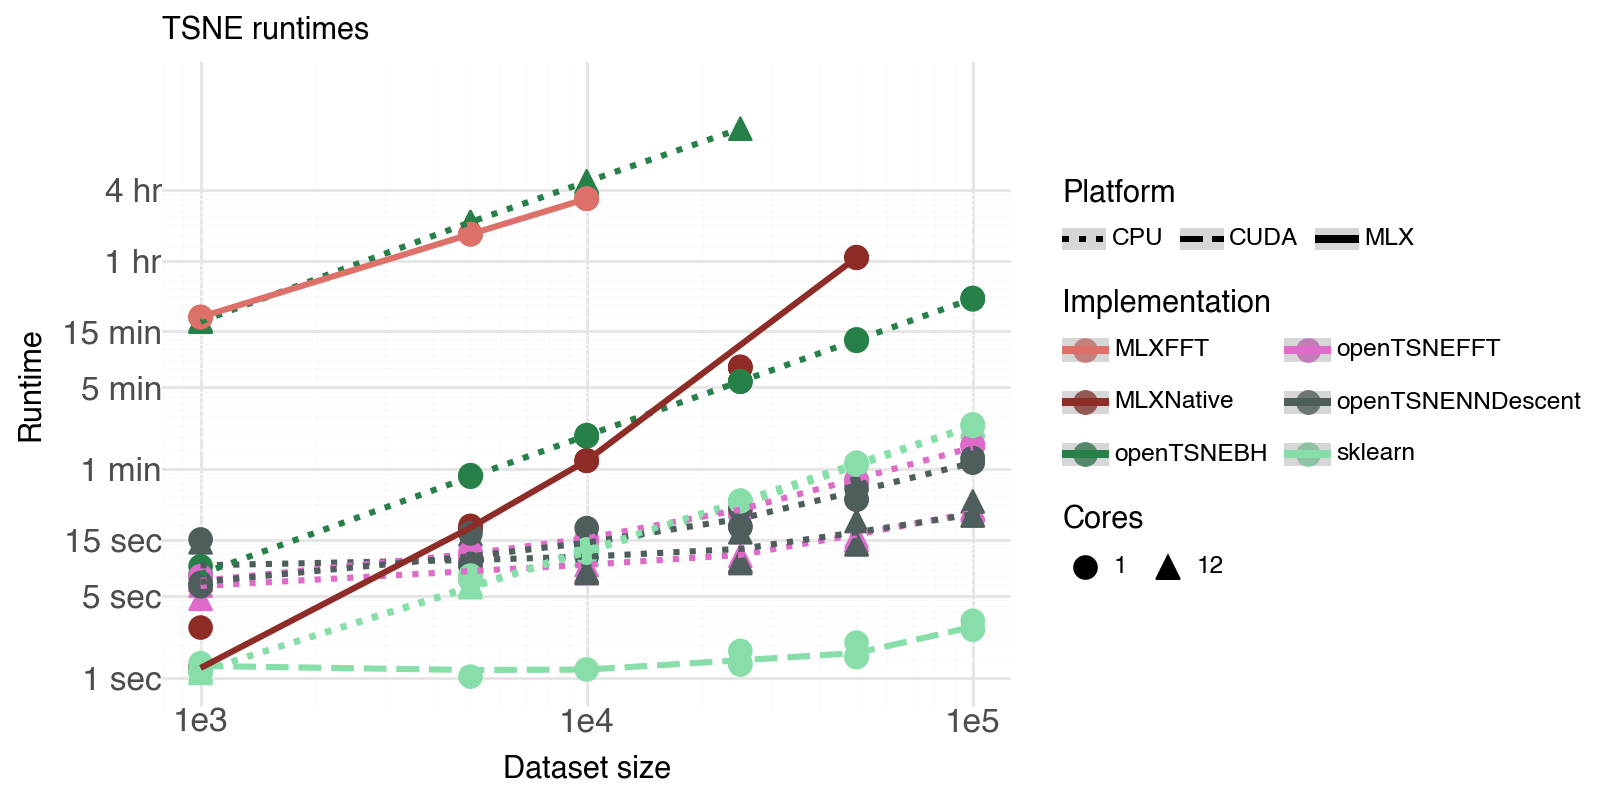

In [51]:
breaks = [1, 5, 15, 60, 300, 3600 / 4, 3600, 4 * 3600]
labels = ['1 sec', '5 sec', '15 sec', '1 min', '5 min', '15 min', '1 hr', '4 hr']

p_ = (
    p.ggplot(
        df,
        p.aes(
            x = 'dataset_size', 
            y = 'runtime', 
            color = 'Implementation', 
            linetype = 'Platform', 
            group = 'Platform + Cores + Implementation', 
            shape = 'Cores'
        )
    )
    + p.geom_point(size = 4)
    + p.geom_smooth(show_legend = True, size = 1.25)
    + p.scale_x_log10()
    + p.scale_y_log10(
        limits=(1, 100_000),  # This is needed for some reason when usig custom labels in scale_y_log10
        breaks=breaks,
        labels=labels
    )
    + p.scale_linetype_manual({'CUDA': 'dashed', 'MLX': 'solid', 'CPU': 'dotted'})
    + p.scale_color_manual({
        'MLXFFT': '#DE706A',
        'MLXNative': '#8E2D27',
        'sklearn': '#87DEA8',
        'openTSNEBH': '#268048',
        'openTSNEFFT': '#DE6ACA',
        'openTSNENNDescent': '#4D5E5D'
    })
    
    + p.theme_minimal()
    + p.theme(
        figure_size=(8, 4),
        axis_text_x=p.element_text(size = 12),
        axis_text_y=p.element_text(size = 12)
    )
    + p.guides(color=p.guide_legend(ncol=2), linetype=p.guide_legend(ncol=3), shape=p.guide_legend(ncol=2))
    
    + p.labs(x = 'Dataset size', y = 'Runtime', subtitle = 'TSNE runtimes')
    + p.theme(plot_background = p.element_rect(fill = 'white', color = 'none'))
)

p_.save('250330.runtimes.png', dpi=300, facecolor='white', transparent=False)

p_